## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
from fuzzywuzzy import fuzz
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from preprocessing_utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x000001EFE84511C0> [RTYPES.NILSXP]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_EL = 'αττικης'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2010-2022_filled_meantemps.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_NUTS3_2010-2022.csv', encoding=enc)

In [5]:
timeline_file.head()

,nuts3,nuts2,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall
0,αθηνων,αττικης,23.760930,37.952630,2010-01-01,1,1,2010,0.121077,0.086852,-0.033350,-0.086852,0.123717,0.087819,-0.034276,-0.087819,0.057889,0.038353,0.013501,0.038353,14624.000000,14325.000000,14624.000000,NaN,NaN,NaN,14325.000000,NaN,NaN,NaN,0.000000
1,αθηνων,αττικης,23.760930,37.952630,2010-01-02,2,1,2010,0.121077,0.086852,-0.033350,-0.086852,0.123717,0.087819,-0.034276,-0.087819,0.057889,0.038353,0.013501,0.038353,14049.000000,14193.000000,14336.500000,NaN,NaN,NaN,14259.000000,NaN,NaN,NaN,0.000000
2,αθηνων,αττικης,23.760930,37.952630,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14049.000000,14074.000000,14240.666667,NaN,NaN,NaN,14197.333333,NaN,NaN,NaN,0.000000
3,αθηνων,αττικης,23.760930,37.952630,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14049.000000,14074.000000,14192.750000,NaN,NaN,NaN,14166.500000,NaN,NaN,NaN,0.000000
4,αθηνων,αττικης,23.760930,37.952630,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14049.000000,14074.000000,14164.000000,NaN,NaN,NaN,14148.000000,NaN,NaN,NaN,0.000000


In [6]:
wnv_file.head()

,nuts2,nuts3,dt_placement,cases
0,αττικης,ανατολικης αττικης,2011-05,0
1,αττικης,ανατολικης αττικης,2011-06,0
2,αττικης,ανατολικης αττικης,2011-07,7
3,αττικης,ανατολικης αττικης,2011-08,8
4,αττικης,ανατολικης αττικης,2011-09,5


In [7]:
timeline_file[['nuts3', 'dt_placement']].value_counts().sort_values(ascending=False)

nuts3               dt_placement
ανατολικης αττικης  2016-07-01      290
                    2022-12-11      290
                    2022-12-27      290
                    2022-12-26      290
                    2022-12-25      290
                                   ... 
αθηνων              2010-01-04       56
                    2010-01-03       56
                    2010-01-09       56
                    2010-01-18       56
                    2010-01-01       56
Length: 18992, dtype: int64

In [8]:
wnv_file[['nuts3', 'dt_placement']].value_counts().sort_values(ascending=False)

nuts3               dt_placement
ανατολικης αττικης  2011-05         1
                    2012-09         1
                    2011-07         1
                    2011-08         1
                    2011-09         1
                                   ..
πειραιως & νησων    2021-07         1
                    2021-08         1
                    2021-09         1
                    2018-10         1
                    2021-10         1
Length: 336, dtype: int64

In [9]:
#timeline_file.drop(columns=['Unnamed: 0'], inplace=True)
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [10]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [11]:
timeline_file = convert_temperature(timeline_file)

In [12]:
timeline_file

,nuts3,nuts2,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean
0,αθηνων,αττικης,23.760930,37.952630,2010-01-01,1,1,2010,0.121077,0.086852,-0.033350,-0.086852,0.123717,0.087819,-0.034276,-0.087819,0.057889,0.038353,0.013501,0.038353,19.330000,13.350000,19.330000,NaN,NaN,NaN,13.350000,NaN,NaN,NaN,0.000000,16.340000,16.340000,NaN,NaN,NaN
1,αθηνων,αττικης,23.760930,37.952630,2010-01-02,2,1,2010,0.121077,0.086852,-0.033350,-0.086852,0.123717,0.087819,-0.034276,-0.087819,0.057889,0.038353,0.013501,0.038353,7.830000,10.710000,13.580000,NaN,NaN,NaN,12.030000,NaN,NaN,NaN,0.000000,9.270000,12.805000,NaN,NaN,NaN
2,αθηνων,αττικης,23.760930,37.952630,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.830000,8.330000,11.663333,NaN,NaN,NaN,10.796667,NaN,NaN,NaN,0.000000,8.080000,11.230000,NaN,NaN,NaN
3,αθηνων,αττικης,23.760930,37.952630,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.830000,8.330000,10.705000,NaN,NaN,NaN,10.180000,NaN,NaN,NaN,0.000000,8.080000,10.442500,NaN,NaN,NaN
4,αθηνων,αττικης,23.760930,37.952630,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.830000,8.330000,10.130000,NaN,NaN,NaN,9.810000,NaN,NaN,NaN,0.000000,8.080000,9.970000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3029219,πειραιως και νησων,αττικης,23.655270,37.969500,2022-12-27,27,12,2022,0.072316,0.012635,-0.083012,-0.012635,0.053833,-0.010063,-0.077402,0.010063,0.011796,0.014127,0.009121,0.014127,16.190000,11.610000,11.856452,15.593571,18.160323,18.160323,6.817097,7.742857,6.683548,6.683548,0.000000,13.900000,9.336774,11.668214,12.421935,12.421935
3029220,πειραιως και νησων,αττικης,23.655270,37.969500,2022-12-28,28,12,2022,0.072316,0.012635,-0.083012,-0.012635,0.053833,-0.010063,-0.077402,0.010063,0.011796,0.014127,0.009121,0.014127,16.730000,10.950000,11.856452,15.593571,18.160323,18.160323,6.817097,7.742857,6.683548,6.683548,0.000000,13.840000,9.336774,11.668214,12.421935,12.421935
3029221,πειραιως και νησων,αττικης,23.655270,37.969500,2022-12-29,29,12,2022,0.072316,0.012635,-0.083012,-0.012635,0.053833,-0.010063,-0.077402,0.010063,0.011796,0.014127,0.009121,0.014127,16.730000,9.730000,11.856452,15.593571,18.160323,18.160323,6.817097,7.742857,6.683548,6.683548,0.000000,13.230000,9.336774,11.668214,12.421935,12.421935
3029222,πειραιως και νησων,αττικης,23.655270,37.969500,2022-12-30,30,12,2022,0.072316,0.012635,-0.083012,-0.012635,0.053833,-0.010063,-0.077402,0.010063,0.011796,0.014127,0.009121,0.014127,15.510000,11.770000,11.856452,15.593571,18.160323,18.160323,6.817097,7.742857,6.683548,6.683548,0.000000,13.640000,9.336774,11.668214,12.421935,12.421935


In [13]:
grouped = timeline_file.groupby(['dt_placement', 'nuts3', 'nuts2'], as_index = False)
dataset_grouped = grouped.mean()
dataset_grouped

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean
0,2010-01-01,αθηνων,αττικης,23.761339,37.995939,1.000000,1.000000,2010.000000,0.214667,0.115770,-0.078831,-0.115770,0.203206,0.109475,-0.076622,-0.109475,0.042789,0.028909,0.031819,0.028909,18.517143,12.496545,18.517143,NaN,NaN,NaN,12.496545,NaN,NaN,NaN,0.000000,15.498000,15.498000,NaN,NaN,NaN
1,2010-01-01,ανατολικης αττικης,αττικης,23.889386,38.042726,1.000000,1.000000,2010.000000,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,18.574390,11.846828,18.574390,NaN,NaN,NaN,11.846828,NaN,NaN,NaN,0.000000,15.226794,15.226794,NaN,NaN,NaN
2,2010-01-01,δυτικης αττικης,αττικης,23.393515,38.090792,1.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.126230,10.741623,18.126230,NaN,NaN,NaN,10.741623,NaN,NaN,NaN,0.000000,14.419789,14.419789,NaN,NaN,NaN
3,2010-01-01,πειραιως και νησων,αττικης,23.209892,37.000012,1.000000,1.000000,2010.000000,0.388580,0.182433,-0.158436,-0.182433,0.372900,0.169919,-0.155610,-0.169919,0.040076,0.038308,0.019148,0.038308,19.481200,13.400986,19.481200,NaN,NaN,NaN,13.400986,NaN,NaN,NaN,0.000000,16.587042,16.587042,NaN,NaN,NaN
4,2010-01-02,αθηνων,αττικης,23.761339,37.995939,2.000000,1.000000,2010.000000,0.214667,0.115770,-0.078831,-0.115770,0.203206,0.109475,-0.076622,-0.109475,0.042789,0.028909,0.031819,0.028909,15.343571,10.459286,16.930357,NaN,NaN,NaN,11.471250,NaN,NaN,NaN,0.000000,12.901429,14.200804,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18987,2022-12-30,πειραιως και νησων,αττικης,23.209892,37.000012,30.000000,12.000000,2022.000000,0.450630,0.194090,-0.336309,-0.194090,0.445607,0.188515,-0.334842,-0.188515,0.050421,0.056673,0.057526,0.056673,14.216000,9.245000,12.079290,14.021750,14.453574,14.453574,5.873361,6.669879,5.424929,5.424929,0.000000,11.730500,8.976326,10.345814,9.939252,9.939252
18988,2022-12-31,αθηνων,αττικης,23.761339,37.995939,31.000000,12.000000,2022.000000,0.196736,0.089225,-0.175720,-0.089225,0.201940,0.083988,-0.180670,-0.083988,0.059159,0.041055,0.047088,0.041055,14.892143,8.986429,10.219435,14.442806,15.885772,15.885772,4.738859,6.727385,4.842961,4.842961,0.000000,11.939286,7.479147,10.585096,10.364366,10.364366
18989,2022-12-31,ανατολικης αττικης,αττικης,23.889386,38.042726,31.000000,12.000000,2022.000000,0.357294,0.096638,-0.294180,-0.096638,0.350256,0.100488,-0.286339,-0.100488,0.052750,0.056148,0.048111,0.056148,13.707241,6.708828,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,0.000000,10.208034,6.815389,9.204958,8.473898,8.473898
18990,2022-12-31,δυτικης αττικης,αττικης,23.393515,38.090792,31.000000,12.000000,2022.000000,0.342190,0.097829,-0.273326,-0.097829,0.344352,0.098926,-0.275504,-0.098926,0.064567,0.066426,0.069173,0.066426,13.470208,6.003229,9.057651,12.746767,13.664163,13.664163,2.835010,4.016749,2.832120,2.832120,0.000000,9.736719,5.946331,8.381758,8.248142,8.248142


In [14]:
dataset = pd.DataFrame()
groups = dataset_grouped.groupby(['x', 'y', 'year'])

for group, data in groups:
    temp_df = data.copy()
    temp_df.reset_index(drop=True, inplace=True)
    temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
    temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
    temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
    dataset = pd.concat([dataset, temp_df])

dataset.reset_index(drop=True, inplace=True)

In [15]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,2010-01-01,πειραιως και νησων,αττικης,23.209892,37.000012,1.000000,1.000000,2010.000000,0.388580,0.182433,-0.158436,-0.182433,0.372900,0.169919,-0.155610,-0.169919,0.040076,0.038308,0.019148,0.038308,19.481200,13.400986,19.481200,NaN,NaN,NaN,13.400986,NaN,NaN,NaN,0.000000,16.587042,16.587042,NaN,NaN,NaN,0.000000,0.000000,0.000000
1,2010-01-02,πειραιως και νησων,αττικης,23.209892,37.000012,2.000000,1.000000,2010.000000,0.388580,0.182433,-0.158436,-0.182433,0.372900,0.169919,-0.155610,-0.169919,0.040076,0.038308,0.019148,0.038308,14.657000,10.903793,17.069100,NaN,NaN,NaN,11.948736,NaN,NaN,NaN,0.000000,12.765402,14.550287,NaN,NaN,NaN,0.000000,0.000000,0.000000
2,2010-01-03,πειραιως και νησων,αττικης,23.209892,37.000012,3.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.794600,9.091379,15.977600,NaN,NaN,NaN,10.977510,NaN,NaN,NaN,0.000001,11.473103,13.515172,NaN,NaN,NaN,0.000001,0.000001,0.000001
3,2010-01-04,πειραιως και νησων,αττικης,23.209892,37.000012,4.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.770200,8.726180,15.175750,NaN,NaN,NaN,10.355056,NaN,NaN,NaN,0.000003,10.761798,12.801180,NaN,NaN,NaN,0.000004,0.000004,0.000004
4,2010-01-05,πειραιως και νησων,αττικης,23.209892,37.000012,5.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.831000,9.152020,14.706800,NaN,NaN,NaN,10.189828,NaN,NaN,NaN,0.000037,10.996667,12.460944,NaN,NaN,NaN,0.000042,0.000042,0.000042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18987,2022-12-27,ανατολικης αττικης,αττικης,23.889386,38.042726,27.000000,12.000000,2022.000000,0.384440,0.082503,-0.320974,-0.082503,0.386191,0.087542,-0.320254,-0.087542,0.052032,0.055752,0.043993,0.055752,15.127103,8.291034,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,0.000000,11.709069,6.815389,9.204958,8.473898,8.473898,0.105312,1.489834,935.296346
18988,2022-12-28,ανατολικης αττικης,αττικης,23.889386,38.042726,28.000000,12.000000,2022.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.016966,7.978345,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,0.000000,11.497655,6.815389,9.204958,8.473898,8.473898,0.105312,1.335275,935.296346
18989,2022-12-29,ανατολικης αττικης,αττικης,23.889386,38.042726,29.000000,12.000000,2022.000000,0.384440,0.082503,-0.320974,-0.082503,0.386191,0.087542,-0.320254,-0.087542,0.052032,0.055752,0.043993,0.055752,14.700345,6.981586,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,0.000000,10.840966,6.815389,9.204958,8.473898,8.473898,0.105312,0.115401,935.296346
18990,2022-12-30,ανατολικης αττικης,αττικης,23.889386,38.042726,30.000000,12.000000,2022.000000,0.384440,0.082503,-0.320974,-0.082503,0.386191,0.087542,-0.320254,-0.087542,0.052032,0.055752,0.043993,0.055752,13.787862,7.294138,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,0.000380,10.541000,6.815389,9.204958,8.473898,8.473898,0.064501,0.115781,935.296726


In [16]:
dataset = dataset.astype({"day":"int","month":"int", "year":"int"})

In [17]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [18]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,2010-01-01,πειραιως και νησων,αττικης,23.209892,37.000012,1,1,2010,0.388580,0.182433,-0.158436,-0.182433,0.372900,0.169919,-0.155610,-0.169919,0.040076,0.038308,0.019148,0.038308,19.481200,13.400986,19.481200,NaN,NaN,NaN,13.400986,NaN,NaN,NaN,0.000000,16.587042,16.587042,NaN,NaN,NaN,0.000000,0.000000,0.000000
1,2010-01-02,πειραιως και νησων,αττικης,23.209892,37.000012,2,1,2010,0.388580,0.182433,-0.158436,-0.182433,0.372900,0.169919,-0.155610,-0.169919,0.040076,0.038308,0.019148,0.038308,14.657000,10.903793,17.069100,NaN,NaN,NaN,11.948736,NaN,NaN,NaN,0.000000,12.765402,14.550287,NaN,NaN,NaN,0.000000,0.000000,0.000000
2,2010-01-03,πειραιως και νησων,αττικης,23.209892,37.000012,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.794600,9.091379,15.977600,NaN,NaN,NaN,10.977510,NaN,NaN,NaN,0.000001,11.473103,13.515172,NaN,NaN,NaN,0.000001,0.000001,0.000001
3,2010-01-04,πειραιως και νησων,αττικης,23.209892,37.000012,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.770200,8.726180,15.175750,NaN,NaN,NaN,10.355056,NaN,NaN,NaN,0.000003,10.761798,12.801180,NaN,NaN,NaN,0.000004,0.000004,0.000004
4,2010-01-05,πειραιως και νησων,αττικης,23.209892,37.000012,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.831000,9.152020,14.706800,NaN,NaN,NaN,10.189828,NaN,NaN,NaN,0.000037,10.996667,12.460944,NaN,NaN,NaN,0.000042,0.000042,0.000042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18987,2022-12-27,ανατολικης αττικης,αττικης,23.889386,38.042726,27,12,2022,0.384440,0.082503,-0.320974,-0.082503,0.386191,0.087542,-0.320254,-0.087542,0.052032,0.055752,0.043993,0.055752,15.127103,8.291034,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,0.000000,11.709069,6.815389,9.204958,8.473898,8.473898,0.105312,1.489834,935.296346
18988,2022-12-28,ανατολικης αττικης,αττικης,23.889386,38.042726,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.016966,7.978345,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,0.000000,11.497655,6.815389,9.204958,8.473898,8.473898,0.105312,1.335275,935.296346
18989,2022-12-29,ανατολικης αττικης,αττικης,23.889386,38.042726,29,12,2022,0.384440,0.082503,-0.320974,-0.082503,0.386191,0.087542,-0.320254,-0.087542,0.052032,0.055752,0.043993,0.055752,14.700345,6.981586,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,0.000000,10.840966,6.815389,9.204958,8.473898,8.473898,0.105312,0.115401,935.296346
18990,2022-12-30,ανατολικης αττικης,αττικης,23.889386,38.042726,30,12,2022,0.384440,0.082503,-0.320974,-0.082503,0.386191,0.087542,-0.320254,-0.087542,0.052032,0.055752,0.043993,0.055752,13.787862,7.294138,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,0.000380,10.541000,6.815389,9.204958,8.473898,8.473898,0.064501,0.115781,935.296726


In [19]:
dataset[['nuts3', 'dt_placement']].value_counts().sort_values(ascending=False)

nuts3               dt_placement
αθηνων              2010-01-01      1
                    2010-01-03      1
                    2010-01-05      1
                    2010-01-06      1
                    2010-01-07      1
                                   ..
πειραιως και νησων  2022-12-29      1
                    2022-12-30      1
                    2022-12-24      1
                    2022-12-15      1
                    2022-12-31      1
Length: 18992, dtype: int64

In [20]:
df_mosquitoes = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_NUTS3_2010-2022.csv', encoding = enc)
df_mosquitoes

,x,y,dt_placement,mosq_pred
0,23.761339,37.995939,2010-01-01,8
1,23.889386,38.042726,2010-01-01,31
2,23.393515,38.090792,2010-01-01,16
3,23.209892,37.000012,2010-01-01,50
4,23.761339,37.995939,2010-01-02,6
...,...,...,...,...
18987,23.209892,37.000012,2022-12-30,7
18988,23.761339,37.995939,2022-12-31,29
18989,23.889386,38.042726,2022-12-31,19
18990,23.393515,38.090792,2022-12-31,28


In [21]:
df_mosquitoes['dt_placement'] = pd.to_datetime(df_mosquitoes['dt_placement'])

In [22]:
dataset['x.approx'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y.approx'] = dataset['y'].apply(lambda x : round(x,5))

df_mosquitoes['x.approx'] = df_mosquitoes['x'].apply(lambda x : round(x,5))
df_mosquitoes['y.approx'] = df_mosquitoes['y'].apply(lambda x : round(x,5))

In [23]:
dataset = pd.merge(dataset, df_mosquitoes,  how='left', on=['x.approx', 'y.approx', 'dt_placement'])

<AxesSubplot:>

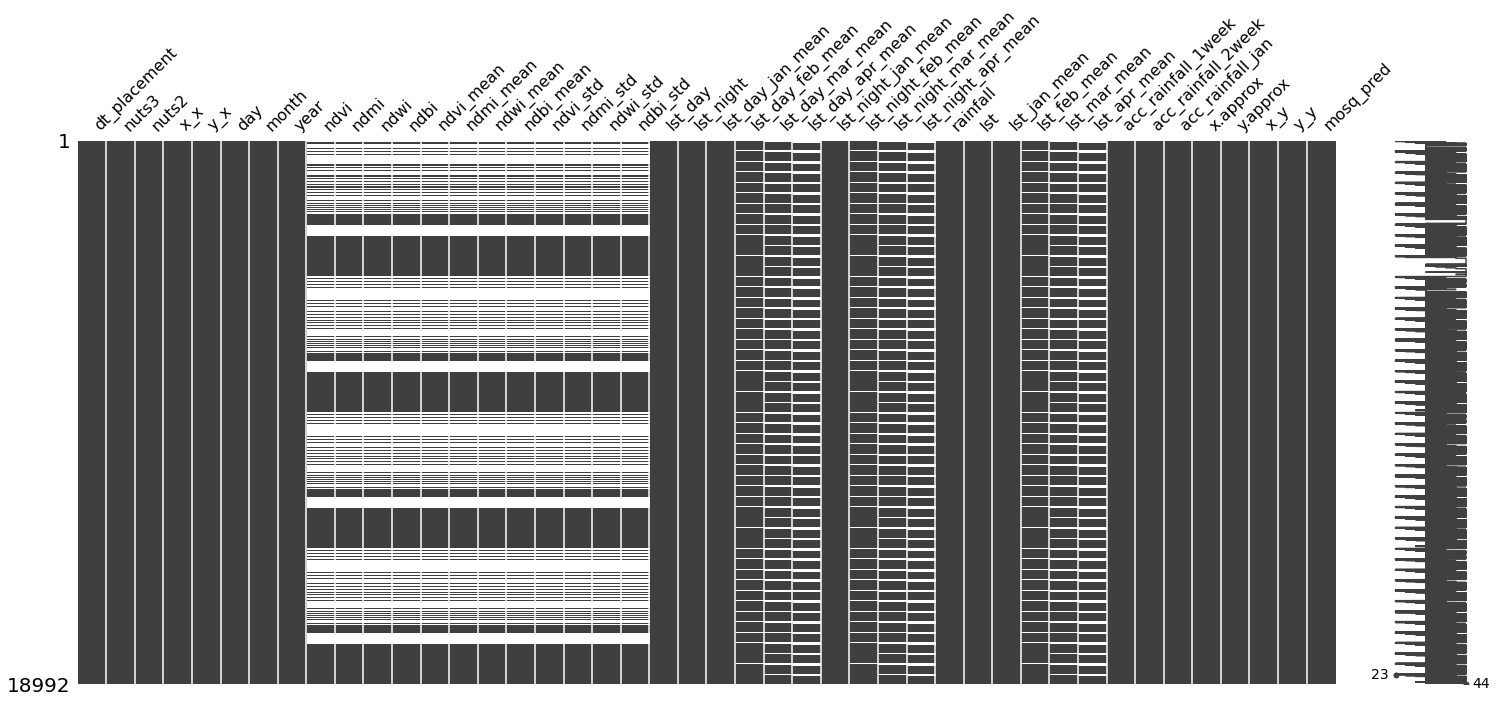

In [24]:
missingno.matrix(dataset)

In [25]:
dataset['distance'] = dataset.apply(lambda row: compute_distance(row, x1='x_x', y1 = 'y_x', x2 = 'x_y', y2 = 'y_y'), axis=1)


In [26]:
dataset.distance.max()

3.534644324911471e-10

In [27]:
dataset.drop(columns=['x.approx', 'y.approx', 'x_y', 'y_y', 'distance'], axis=1, inplace=True)
dataset.rename(columns={"x_x": "x", "y_x": "y"}, inplace=True)

In [28]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred
0,2010-01-01,πειραιως και νησων,αττικης,23.209892,37.000012,1,1,2010,0.388580,0.182433,-0.158436,-0.182433,0.372900,0.169919,-0.155610,-0.169919,0.040076,0.038308,0.019148,0.038308,19.481200,13.400986,19.481200,NaN,NaN,NaN,13.400986,NaN,NaN,NaN,0.000000,16.587042,16.587042,NaN,NaN,NaN,0.000000,0.000000,0.000000,50
1,2010-01-02,πειραιως και νησων,αττικης,23.209892,37.000012,2,1,2010,0.388580,0.182433,-0.158436,-0.182433,0.372900,0.169919,-0.155610,-0.169919,0.040076,0.038308,0.019148,0.038308,14.657000,10.903793,17.069100,NaN,NaN,NaN,11.948736,NaN,NaN,NaN,0.000000,12.765402,14.550287,NaN,NaN,NaN,0.000000,0.000000,0.000000,45
2,2010-01-03,πειραιως και νησων,αττικης,23.209892,37.000012,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.794600,9.091379,15.977600,NaN,NaN,NaN,10.977510,NaN,NaN,NaN,0.000001,11.473103,13.515172,NaN,NaN,NaN,0.000001,0.000001,0.000001,22
3,2010-01-04,πειραιως και νησων,αττικης,23.209892,37.000012,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.770200,8.726180,15.175750,NaN,NaN,NaN,10.355056,NaN,NaN,NaN,0.000003,10.761798,12.801180,NaN,NaN,NaN,0.000004,0.000004,0.000004,3
4,2010-01-05,πειραιως και νησων,αττικης,23.209892,37.000012,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.831000,9.152020,14.706800,NaN,NaN,NaN,10.189828,NaN,NaN,NaN,0.000037,10.996667,12.460944,NaN,NaN,NaN,0.000042,0.000042,0.000042,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18987,2022-12-27,ανατολικης αττικης,αττικης,23.889386,38.042726,27,12,2022,0.384440,0.082503,-0.320974,-0.082503,0.386191,0.087542,-0.320254,-0.087542,0.052032,0.055752,0.043993,0.055752,15.127103,8.291034,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,0.000000,11.709069,6.815389,9.204958,8.473898,8.473898,0.105312,1.489834,935.296346,14
18988,2022-12-28,ανατολικης αττικης,αττικης,23.889386,38.042726,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.016966,7.978345,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,0.000000,11.497655,6.815389,9.204958,8.473898,8.473898,0.105312,1.335275,935.296346,17
18989,2022-12-29,ανατολικης αττικης,αττικης,23.889386,38.042726,29,12,2022,0.384440,0.082503,-0.320974,-0.082503,0.386191,0.087542,-0.320254,-0.087542,0.052032,0.055752,0.043993,0.055752,14.700345,6.981586,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,0.000000,10.840966,6.815389,9.204958,8.473898,8.473898,0.105312,0.115401,935.296346,17
18990,2022-12-30,ανατολικης αττικης,αττικης,23.889386,38.042726,30,12,2022,0.384440,0.082503,-0.320974,-0.082503,0.386191,0.087542,-0.320254,-0.087542,0.052032,0.055752,0.043993,0.055752,13.787862,7.294138,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,0.000380,10.541000,6.815389,9.204958,8.473898,8.473898,0.064501,0.115781,935.296726,18


In [29]:
bio_values = []

for region in dataset.nuts3.unique():
    for year in dataset.year.unique():
        for month in dataset.month.unique():
            filtered_df = dataset.loc[(dataset['year'] == year) & (dataset['nuts3'] == region) & (dataset['month'] == month)].copy()
            tmin = min(filtered_df['lst_day'].min(), filtered_df['lst_night'].min())
            tmax = max(filtered_df['lst_day'].max(), filtered_df['lst_night'].max())
            prec = filtered_df['rainfall'].sum()
            bio_values.append({'nuts3': region, 
                               'year': year, 
                               'month': month, 
                               'monthly_lst_min': tmin, 
                               'monthly_lst_max': tmax,
                               'monthly_acc_prec': prec})

In [30]:
bio_values_df = pd.DataFrame(bio_values)

In [31]:
dataset = pd.merge(dataset, bio_values_df, on=['nuts3', 'year', 'month'], how='left')

In [32]:
dataset

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01-01,πειραιως και νησων,αττικης,23.209892,37.000012,1,1,2010,0.388580,0.182433,-0.158436,-0.182433,0.372900,0.169919,-0.155610,-0.169919,0.040076,0.038308,0.019148,0.038308,19.481200,13.400986,19.481200,NaN,NaN,NaN,13.400986,NaN,NaN,NaN,0.000000,16.587042,16.587042,NaN,NaN,NaN,0.000000,0.000000,0.000000,50,2.782400,19.481200,170.152710
1,2010-01-02,πειραιως και νησων,αττικης,23.209892,37.000012,2,1,2010,0.388580,0.182433,-0.158436,-0.182433,0.372900,0.169919,-0.155610,-0.169919,0.040076,0.038308,0.019148,0.038308,14.657000,10.903793,17.069100,NaN,NaN,NaN,11.948736,NaN,NaN,NaN,0.000000,12.765402,14.550287,NaN,NaN,NaN,0.000000,0.000000,0.000000,45,2.782400,19.481200,170.152710
2,2010-01-03,πειραιως και νησων,αττικης,23.209892,37.000012,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.794600,9.091379,15.977600,NaN,NaN,NaN,10.977510,NaN,NaN,NaN,0.000001,11.473103,13.515172,NaN,NaN,NaN,0.000001,0.000001,0.000001,22,2.782400,19.481200,170.152710
3,2010-01-04,πειραιως και νησων,αττικης,23.209892,37.000012,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.770200,8.726180,15.175750,NaN,NaN,NaN,10.355056,NaN,NaN,NaN,0.000003,10.761798,12.801180,NaN,NaN,NaN,0.000004,0.000004,0.000004,3,2.782400,19.481200,170.152710
4,2010-01-05,πειραιως και νησων,αττικης,23.209892,37.000012,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.831000,9.152020,14.706800,NaN,NaN,NaN,10.189828,NaN,NaN,NaN,0.000037,10.996667,12.460944,NaN,NaN,NaN,0.000042,0.000042,0.000042,4,2.782400,19.481200,170.152710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18987,2022-12-27,ανατολικης αττικης,αττικης,23.889386,38.042726,27,12,2022,0.384440,0.082503,-0.320974,-0.082503,0.386191,0.087542,-0.320254,-0.087542,0.052032,0.055752,0.043993,0.055752,15.127103,8.291034,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,0.000000,11.709069,6.815389,9.204958,8.473898,8.473898,0.105312,1.489834,935.296346,14,3.799241,17.022207,57.551790
18988,2022-12-28,ανατολικης αττικης,αττικης,23.889386,38.042726,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.016966,7.978345,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,0.000000,11.497655,6.815389,9.204958,8.473898,8.473898,0.105312,1.335275,935.296346,17,3.799241,17.022207,57.551790
18989,2022-12-29,ανατολικης αττικης,αττικης,23.889386,38.042726,29,12,2022,0.384440,0.082503,-0.320974,-0.082503,0.386191,0.087542,-0.320254,-0.087542,0.052032,0.055752,0.043993,0.055752,14.700345,6.981586,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,0.000000,10.840966,6.815389,9.204958,8.473898,8.473898,0.105312,0.115401,935.296346,17,3.799241,17.022207,57.551790
18990,2022-12-30,ανατολικης αττικης,αττικης,23.889386,38.042726,30,12,2022,0.384440,0.082503,-0.320974,-0.082503,0.386191,0.087542,-0.320254,-0.087542,0.052032,0.055752,0.043993,0.055752,13.787862,7.294138,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,0.000380,10.541000,6.815389,9.204958,8.473898,8.473898,0.064501,0.115781,935.296726,18,3.799241,17.022207,57.551790


<AxesSubplot:>

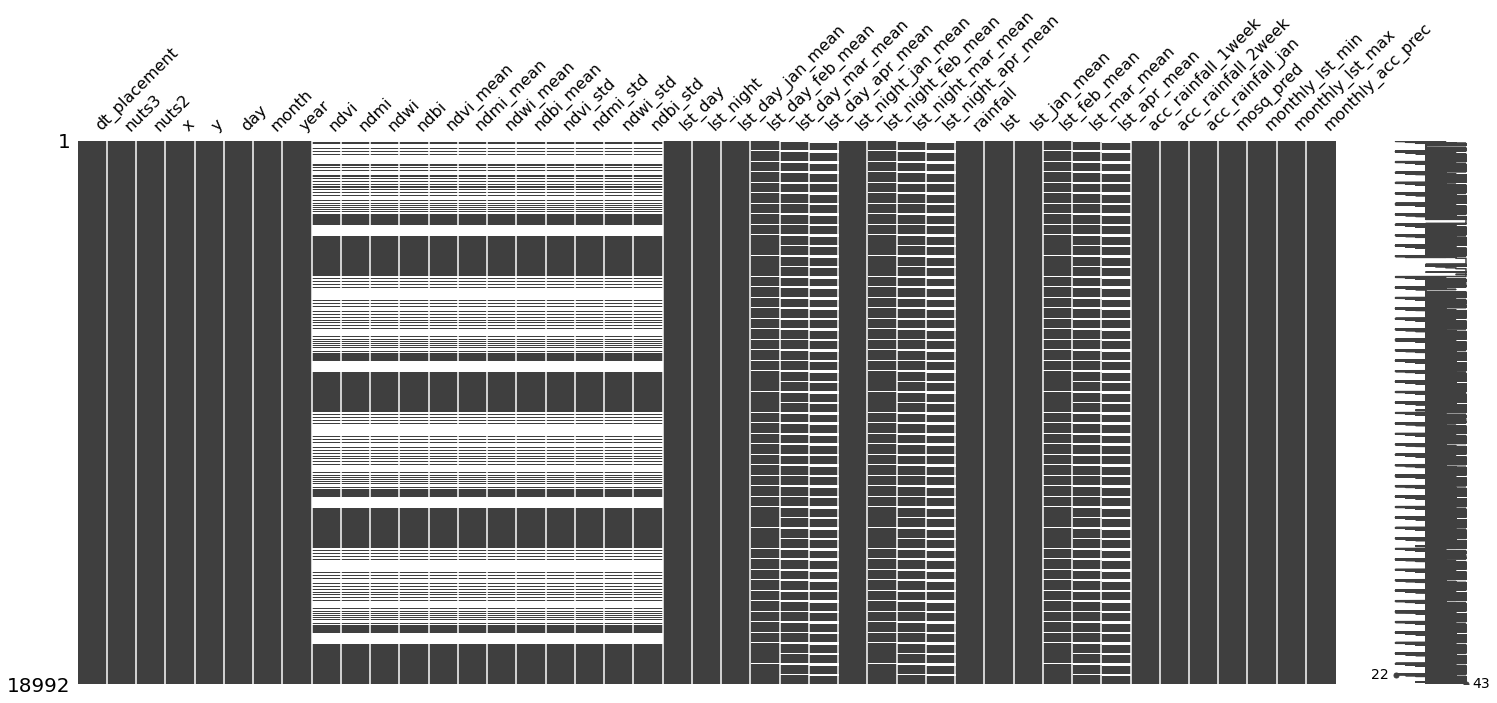

In [33]:
missingno.matrix(dataset)

In [34]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)

In [35]:
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [36]:
dataset

,dt_placement_daily,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,dt_placement
0,2010-01-01,πειραιως και νησων,αττικης,23.209892,37.000012,1,1,2010,0.388580,0.182433,-0.158436,-0.182433,0.372900,0.169919,-0.155610,-0.169919,0.040076,0.038308,0.019148,0.038308,19.481200,13.400986,19.481200,NaN,NaN,NaN,13.400986,NaN,NaN,NaN,0.000000,16.587042,16.587042,NaN,NaN,NaN,0.000000,0.000000,0.000000,50,2.782400,19.481200,170.152710,2010-01
1,2010-01-02,πειραιως και νησων,αττικης,23.209892,37.000012,2,1,2010,0.388580,0.182433,-0.158436,-0.182433,0.372900,0.169919,-0.155610,-0.169919,0.040076,0.038308,0.019148,0.038308,14.657000,10.903793,17.069100,NaN,NaN,NaN,11.948736,NaN,NaN,NaN,0.000000,12.765402,14.550287,NaN,NaN,NaN,0.000000,0.000000,0.000000,45,2.782400,19.481200,170.152710,2010-01
2,2010-01-03,πειραιως και νησων,αττικης,23.209892,37.000012,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.794600,9.091379,15.977600,NaN,NaN,NaN,10.977510,NaN,NaN,NaN,0.000001,11.473103,13.515172,NaN,NaN,NaN,0.000001,0.000001,0.000001,22,2.782400,19.481200,170.152710,2010-01
3,2010-01-04,πειραιως και νησων,αττικης,23.209892,37.000012,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.770200,8.726180,15.175750,NaN,NaN,NaN,10.355056,NaN,NaN,NaN,0.000003,10.761798,12.801180,NaN,NaN,NaN,0.000004,0.000004,0.000004,3,2.782400,19.481200,170.152710,2010-01
4,2010-01-05,πειραιως και νησων,αττικης,23.209892,37.000012,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.831000,9.152020,14.706800,NaN,NaN,NaN,10.189828,NaN,NaN,NaN,0.000037,10.996667,12.460944,NaN,NaN,NaN,0.000042,0.000042,0.000042,4,2.782400,19.481200,170.152710,2010-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18987,2022-12-27,ανατολικης αττικης,αττικης,23.889386,38.042726,27,12,2022,0.384440,0.082503,-0.320974,-0.082503,0.386191,0.087542,-0.320254,-0.087542,0.052032,0.055752,0.043993,0.055752,15.127103,8.291034,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,0.000000,11.709069,6.815389,9.204958,8.473898,8.473898,0.105312,1.489834,935.296346,14,3.799241,17.022207,57.551790,2022-12
18988,2022-12-28,ανατολικης αττικης,αττικης,23.889386,38.042726,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.016966,7.978345,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,0.000000,11.497655,6.815389,9.204958,8.473898,8.473898,0.105312,1.335275,935.296346,17,3.799241,17.022207,57.551790,2022-12
18989,2022-12-29,ανατολικης αττικης,αττικης,23.889386,38.042726,29,12,2022,0.384440,0.082503,-0.320974,-0.082503,0.386191,0.087542,-0.320254,-0.087542,0.052032,0.055752,0.043993,0.055752,14.700345,6.981586,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,0.000000,10.840966,6.815389,9.204958,8.473898,8.473898,0.105312,0.115401,935.296346,17,3.799241,17.022207,57.551790,2022-12
18990,2022-12-30,ανατολικης αττικης,αττικης,23.889386,38.042726,30,12,2022,0.384440,0.082503,-0.320974,-0.082503,0.386191,0.087542,-0.320254,-0.087542,0.052032,0.055752,0.043993,0.055752,13.787862,7.294138,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,0.000380,10.541000,6.815389,9.204958,8.473898,8.473898,0.064501,0.115781,935.296726,18,3.799241,17.022207,57.551790,2022-12


In [37]:
grouped = dataset.groupby(['dt_placement', 'nuts3', 'nuts2'], as_index = False)
grouped_mosq = dataset.groupby(['dt_placement', 'nuts3', 'nuts2'], as_index = False)


dataset_month = grouped.mean()
dataset_month_mosq = grouped.sum()


dataset_month

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01,αθηνων,αττικης,23.761339,37.995939,16.000000,1.000000,2010.000000,0.214667,0.115770,-0.078831,-0.115770,0.203206,0.109475,-0.076622,-0.109475,0.042789,0.028909,0.031819,0.028909,12.516682,6.346766,14.751865,NaN,NaN,NaN,8.568003,NaN,NaN,NaN,3.697714,9.431439,11.659648,NaN,NaN,NaN,24.216369,40.673503,45.577861,3.129032,0.007500,18.517143,114.629143
1,2010-01,ανατολικης αττικης,αττικης,23.889386,38.042726,16.000000,1.000000,2010.000000,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,11.589957,5.813515,13.768236,NaN,NaN,NaN,7.672467,NaN,NaN,NaN,3.905487,8.702258,10.720874,NaN,NaN,NaN,25.460487,41.766648,46.576365,7.483871,1.772276,18.574390,121.070102
2,2010-01,δυτικης αττικης,αττικης,23.393515,38.090792,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.584146,4.510271,12.741392,NaN,NaN,NaN,6.649009,NaN,NaN,NaN,3.646743,7.546752,9.694744,NaN,NaN,NaN,23.488678,39.265744,43.997110,14.096774,-0.195625,18.126230,113.049047
3,2010-01,πειραιως και νησων,αττικης,23.209892,37.000012,16.000000,1.000000,2010.000000,0.388580,0.182433,-0.158436,-0.182433,0.372900,0.169919,-0.155610,-0.169919,0.040076,0.038308,0.019148,0.038308,12.326800,7.713573,14.072186,NaN,NaN,NaN,9.693287,NaN,NaN,NaN,5.488797,10.025987,11.891554,NaN,NaN,NaN,37.434509,67.245712,77.617295,5.967742,2.782400,19.481200,170.152710
4,2010-02,αθηνων,αττικης,23.761339,37.995939,14.500000,2.000000,2010.000000,0.170071,0.080282,-0.093162,-0.080282,0.165450,0.077220,-0.091478,-0.077220,0.032154,0.021483,0.020596,0.021483,13.964286,7.778533,12.516682,11.759552,NaN,NaN,6.344478,6.162053,NaN,NaN,4.657489,10.871409,9.430580,8.960803,NaN,NaN,34.319534,76.056410,205.750671,1.178571,1.092857,18.563929,130.409681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,2022-11,πειραιως και νησων,αττικης,23.209892,37.000012,15.500000,11.000000,2022.000000,0.370619,0.113605,-0.294179,-0.113605,0.355679,0.109782,-0.282355,-0.109782,0.047718,0.057267,0.043914,0.057267,19.395300,12.789193,12.079290,14.021750,14.453574,14.453574,5.873361,6.669879,5.424929,5.424929,10.540251,16.092247,8.976326,10.345814,9.939252,9.939252,52.947117,92.511190,1148.815671,16.000000,7.858800,26.901200,316.207543
620,2022-12,αθηνων,αττικης,23.761339,37.995939,16.000000,12.000000,2022.000000,0.184218,0.090565,-0.163560,-0.090565,0.185013,0.090055,-0.161787,-0.090055,0.052146,0.037470,0.044624,0.037470,15.013180,9.219124,10.219435,14.442806,15.885772,15.885772,4.738859,6.727385,4.842961,4.842961,2.306422,12.116152,7.479147,10.585096,10.364366,10.364366,38.951568,93.138216,814.923762,47.580645,5.100714,18.903214,71.499082
621,2022-12,ανατολικης αττικης,αττικης,23.889386,38.042726,16.000000,12.000000,2022.000000,0.306210,0.101422,-0.241399,-0.101422,0.300153,0.105547,-0.234523,-0.105547,0.046141,0.048308,0.043395,0.048308,14.411019,7.452890,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,1.856509,10.931954,6.815389,9.204958,8.473898,8.473898,37.502389,88.946031,918.011340,31.225806,3.799241,17.022207,57.551790
622,2022-12,δυτικης αττικης,αττικης,23.393515,38.090792,16.000000,12.000000,2022.000000,0.301341,0.084213,-0.240944,-0.084213,0.291299,0.089459,-0.229135,-0.089459,0.052933,0.053425,0.054772,0.053425,14.065131,6.084913,9.057651,12.746767,13.664163,13.664163,2.835010,4.016749,2.832120,2.832120,

In [38]:
dataset_month_mosq

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01,αθηνων,αττικης,736.601501,1177.874118,496,31,62310,0.429333,0.231539,-0.157663,-0.231539,0.406412,0.218951,-0.153244,-0.218951,0.085579,0.057818,0.063638,0.057818,388.017143,196.749760,457.307805,0.000000,0.000000,0.000000,265.608085,0.000000,0.000000,0.000000,114.629143,292.374607,361.449101,0.000000,0.000000,0.000000,750.707429,1260.878583,1412.913703,97,0.232500,574.031429,3553.503428
1,2010-01,ανατολικης αττικης,αττικης,740.570962,1179.324521,496,31,62310,0.795541,0.310767,-0.398554,-0.310767,0.798481,0.320715,-0.387846,-0.320715,0.075505,0.071183,0.078438,0.071183,359.288666,180.218966,426.815315,0.000000,0.000000,0.000000,237.846491,0.000000,0.000000,0.000000,121.070102,269.770001,332.347088,0.000000,0.000000,0.000000,789.275101,1294.766080,1443.867320,232,54.940552,575.806098,3753.173158
2,2010-01,δυτικης αττικης,αττικης,725.198962,1180.814542,496,31,62310,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,328.108522,139.818394,394.983138,0.000000,0.000000,0.000000,206.119276,0.000000,0.000000,0.000000,113.049047,233.949321,300.537070,0.000000,0.000000,0.000000,728.149029,1217.238059,1363.910404,437,-6.064375,561.913141,3504.520452
3,2010-01,πειραιως και νησων,αττικης,719.506661,1147.000372,496,31,62310,0.777161,0.364865,-0.316872,-0.364865,0.745799,0.339839,-0.311220,-0.339839,0.080151,0.076615,0.038296,0.076615,382.130800,239.120758,436.237781,0.000000,0.000000,0.000000,300.491884,0.000000,0.000000,0.000000,170.152710,310.805612,368.638176,0.000000,0.000000,0.000000,1160.469787,2084.617057,2406.136145,185,86.254400,603.917200,5274.734007
4,2010-02,αθηνων,αττικης,665.317485,1063.886300,406,56,56280,0.340143,0.160564,-0.186325,-0.160564,0.330899,0.154441,-0.182956,-0.154441,0.064308,0.042966,0.041191,0.042966,391.000000,217.798929,350.467097,329.267450,0.000000,0.000000,177.645387,172.537492,0.000000,0.000000,130.409681,304.399464,264.056242,250.902471,0.000000,0.000000,960.946960,2129.579489,5761.018786,33,30.600000,519.790000,3651.471077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,2022-11,πειραιως και νησων,αττικης,696.296769,1110.000360,465,330,60660,11.118581,3.408140,-8.825378,-3.408140,10.670363,3.293473,-8.470651,-3.293473,1.431554,1.718010,1.317415,1.718010,581.859000,383.675800,362.378710,420.652500,433.607226,433.607226,176.200839,200.096357,162.747871,162.747871,316.207543,482.767400,269.289774,310.374429,298.177548,298.177548,1588.413511,2775.335689,34464.470116,480,235.764000,807.036000,9486.226300
620,2022-12,αθηνων,αττικης,736.601501,1177.874118,496,372,62682,4.605448,2.264136,-4.088999,-2.264136,4.625332,2.251380,-4.044679,-2.251380,1.303653,0.936745,1.115609,0.936745,465.408571,285.792857,316.802500,447.726990,492.458929,492.458929,146.904643,208.548941,150.131786,150.131786,71.499082,375.600714,231.853571,328.137966,321.295357,321.295357,1207.498599,2887.284686,25262.636624,1475,158.122143,585.999643,2216.471545
621,2022-12,ανατολικης αττικης,αττικης,740.570962,1179.324521,496,372,62682,7.655250,2.535559,-6.034972,-2.535559,7.503824,2.638676,-5.863071,-2.638676,1.153529,1.207710,1.084880,1.207710,446.741586,231.039586,316.964276,422.373626,424.445724,424.445724,105.589862,148.333778,100.935931,100.935931,57.551790,338.890586,211.277069,285.353702,262.690828,262.690828,1162.574064,2757.326960,28458.351530,968,117.776483,527.688414,

In [39]:
dataset_month['mosq_pred'] = dataset_month_mosq['mosq_pred']

In [40]:
wnv_file.head(5)

,nuts2,nuts3,dt_placement,cases
0,αττικης,ανατολικης αττικης,2011-05,0
1,αττικης,ανατολικης αττικης,2011-06,0
2,αττικης,ανατολικης αττικης,2011-07,7
3,αττικης,ανατολικης αττικης,2011-08,8
4,αττικης,ανατολικης αττικης,2011-09,5


In [41]:
dataset_month.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 624 entries, 0 to 623
Data columns (total 43 columns):
 #   Column              Non-Null Count  Dtype    
---  ------              --------------  -----    
 0   dt_placement        624 non-null    period[M]
 1   nuts3               624 non-null    object   
 2   nuts2               624 non-null    object   
 3   x                   624 non-null    float64  
 4   y                   624 non-null    float64  
 5   day                 624 non-null    float64  
 6   month               624 non-null    float64  
 7   year                624 non-null    float64  
 8   ndvi                616 non-null    float64  
 9   ndmi                616 non-null    float64  
 10  ndwi                616 non-null    float64  
 11  ndbi                616 non-null    float64  
 12  ndvi_mean           616 non-null    float64  
 13  ndmi_mean           616 non-null    float64  
 14  ndwi_mean           616 non-null    float64  
 15  ndbi_mean           616

In [42]:
wnv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   nuts2         336 non-null    object
 1   nuts3         336 non-null    object
 2   dt_placement  336 non-null    object
 3   cases         336 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 10.6+ KB


In [43]:
wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [44]:
wnv_file

,nuts2,nuts3,dt_placement,cases
0,αττικης,ανατολικης αττικης,2011-05,0
1,αττικης,ανατολικης αττικης,2011-06,0
2,αττικης,ανατολικης αττικης,2011-07,7
3,αττικης,ανατολικης αττικης,2011-08,8
4,αττικης,ανατολικης αττικης,2011-09,5
...,...,...,...,...
331,αττικης,πειραιως & νησων,2021-06,0
332,αττικης,πειραιως & νησων,2021-07,0
333,αττικης,πειραιως & νησων,2021-08,0
334,αττικης,πειραιως & νησων,2021-09,0


In [45]:
wnv_file['cases'].value_counts()

0     269
1      35
4       5
8       4
5       4
7       3
2       3
6       2
3       2
11      1
15      1
10      1
18      1
16      1
12      1
33      1
9       1
20      1
Name: cases, dtype: int64

In [46]:
wnv_file.cases.sum()

296

In [48]:
names_from_wnv = wnv_file["nuts3"].drop_duplicates().sort_values().tolist()
names_from_timeline = dataset_month["nuts3"].drop_duplicates().sort_values().tolist()

diff = []

for element in names_from_wnv:
    if element not in names_from_timeline:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['βορειου τομεα αθηνων', 'δυτικου τομεα αθηνων', 'κεντρικου τομεα αθηνων', 'νοτιου τομεα αθηνων', 'πειραιως & νησων']

Length: 5


In [49]:
wnv_file['nuts3'] = wnv_file['nuts3'].apply(lambda x : x.replace('βορειου τομεα αθηνων','αθηνων'))
wnv_file['nuts3'] = wnv_file['nuts3'].apply(lambda x : x.replace('δυτικου τομεα αθηνων','αθηνων'))
wnv_file['nuts3'] = wnv_file['nuts3'].apply(lambda x : x.replace('κεντρικου τομεα αθηνων','αθηνων'))
wnv_file['nuts3'] = wnv_file['nuts3'].apply(lambda x : x.replace('νοτιου τομεα αθηνων','αθηνων'))
wnv_file['nuts3'] = wnv_file['nuts3'].apply(lambda x : x.replace('πειραιως & νησων','πειραιως και νησων'))

In [50]:
names_from_wnv = wnv_file["nuts3"].drop_duplicates().sort_values().tolist()
names_from_timeline = dataset_month["nuts3"].drop_duplicates().sort_values().tolist()

diff = []

for element in names_from_wnv:
    if element not in names_from_timeline:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")


[]

Length: 0


In [51]:
merged = dataset_month.merge(wnv_file, how='left', on=['dt_placement', 'nuts3', 'nuts2'] )

In [52]:
merged

,dt_placement,nuts3,nuts2,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases
0,2010-01,αθηνων,αττικης,23.761339,37.995939,16.000000,1.000000,2010.000000,0.214667,0.115770,-0.078831,-0.115770,0.203206,0.109475,-0.076622,-0.109475,0.042789,0.028909,0.031819,0.028909,12.516682,6.346766,14.751865,NaN,NaN,NaN,8.568003,NaN,NaN,NaN,3.697714,9.431439,11.659648,NaN,NaN,NaN,24.216369,40.673503,45.577861,97,0.007500,18.517143,114.629143,NaN
1,2010-01,ανατολικης αττικης,αττικης,23.889386,38.042726,16.000000,1.000000,2010.000000,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,11.589957,5.813515,13.768236,NaN,NaN,NaN,7.672467,NaN,NaN,NaN,3.905487,8.702258,10.720874,NaN,NaN,NaN,25.460487,41.766648,46.576365,232,1.772276,18.574390,121.070102,NaN
2,2010-01,δυτικης αττικης,αττικης,23.393515,38.090792,16.000000,1.000000,2010.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.584146,4.510271,12.741392,NaN,NaN,NaN,6.649009,NaN,NaN,NaN,3.646743,7.546752,9.694744,NaN,NaN,NaN,23.488678,39.265744,43.997110,437,-0.195625,18.126230,113.049047,NaN
3,2010-01,πειραιως και νησων,αττικης,23.209892,37.000012,16.000000,1.000000,2010.000000,0.388580,0.182433,-0.158436,-0.182433,0.372900,0.169919,-0.155610,-0.169919,0.040076,0.038308,0.019148,0.038308,12.326800,7.713573,14.072186,NaN,NaN,NaN,9.693287,NaN,NaN,NaN,5.488797,10.025987,11.891554,NaN,NaN,NaN,37.434509,67.245712,77.617295,185,2.782400,19.481200,170.152710,NaN
4,2010-02,αθηνων,αττικης,23.761339,37.995939,14.500000,2.000000,2010.000000,0.170071,0.080282,-0.093162,-0.080282,0.165450,0.077220,-0.091478,-0.077220,0.032154,0.021483,0.020596,0.021483,13.964286,7.778533,12.516682,11.759552,NaN,NaN,6.344478,6.162053,NaN,NaN,4.657489,10.871409,9.430580,8.960803,NaN,NaN,34.319534,76.056410,205.750671,33,1.092857,18.563929,130.409681,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,2022-11,πειραιως και νησων,αττικης,23.209892,37.000012,15.500000,11.000000,2022.000000,0.370619,0.113605,-0.294179,-0.113605,0.355679,0.109782,-0.282355,-0.109782,0.047718,0.057267,0.043914,0.057267,19.395300,12.789193,12.079290,14.021750,14.453574,14.453574,5.873361,6.669879,5.424929,5.424929,10.540251,16.092247,8.976326,10.345814,9.939252,9.939252,52.947117,92.511190,1148.815671,480,7.858800,26.901200,316.207543,NaN
764,2022-12,αθηνων,αττικης,23.761339,37.995939,16.000000,12.000000,2022.000000,0.184218,0.090565,-0.163560,-0.090565,0.185013,0.090055,-0.161787,-0.090055,0.052146,0.037470,0.044624,0.037470,15.013180,9.219124,10.219435,14.442806,15.885772,15.885772,4.738859,6.727385,4.842961,4.842961,2.306422,12.116152,7.479147,10.585096,10.364366,10.364366,38.951568,93.138216,814.923762,1475,5.100714,18.903214,71.499082,NaN
765,2022-12,ανατολικης αττικης,αττικης,23.889386,38.042726,16.000000,12.000000,2022.000000,0.306210,0.101422,-0.241399,-0.101422,0.300153,0.105547,-0.234523,-0.105547,0.046141,0.048308,0.043395,0.048308,14.411019,7.452890,10.224654,13.624956,13.691798,13.691798,3.406125,4.784961,3.255998,3.255998,1.856509,10.931954,6.815389,9.204958,8.473898,8.473898,37.502389,88.946031,918.011340,968,3.799241,17.022207,57.551790,NaN
766,2022-12,δυτικης αττικης,αττικης,23.393515,38.090792,16.000000,12.000000,2022.000000,0.301341,0.084213,-0.240944,-0.084213,0.291299,0.089459,-0.229135,-0.089459,0.052933,0.053425,0.054772,0.053425,14.065131,6.084913,9.057651,12.746767,13.664163,13.664163,2.835010,4.016749,2.832120,2.832120,2.4

In [53]:
merged = fillna(merged,{'cases': 0})

In [54]:
merged['cases'].value_counts()

0.000000     701
1.000000      35
4.000000       5
8.000000       4
5.000000       4
7.000000       3
2.000000       3
6.000000       2
3.000000       2
10.000000      1
33.000000      1
18.000000      1
9.000000       1
16.000000      1
20.000000      1
15.000000      1
12.000000      1
11.000000      1
Name: cases, dtype: int64

In [55]:
merged.cases.sum()

296.0

In [56]:
merged = merged.astype({'day':'int', 'month':'int', 'year':'int', 'cases': 'int'})

In [57]:
merged.drop(columns=['day'], inplace=True)

<AxesSubplot:>

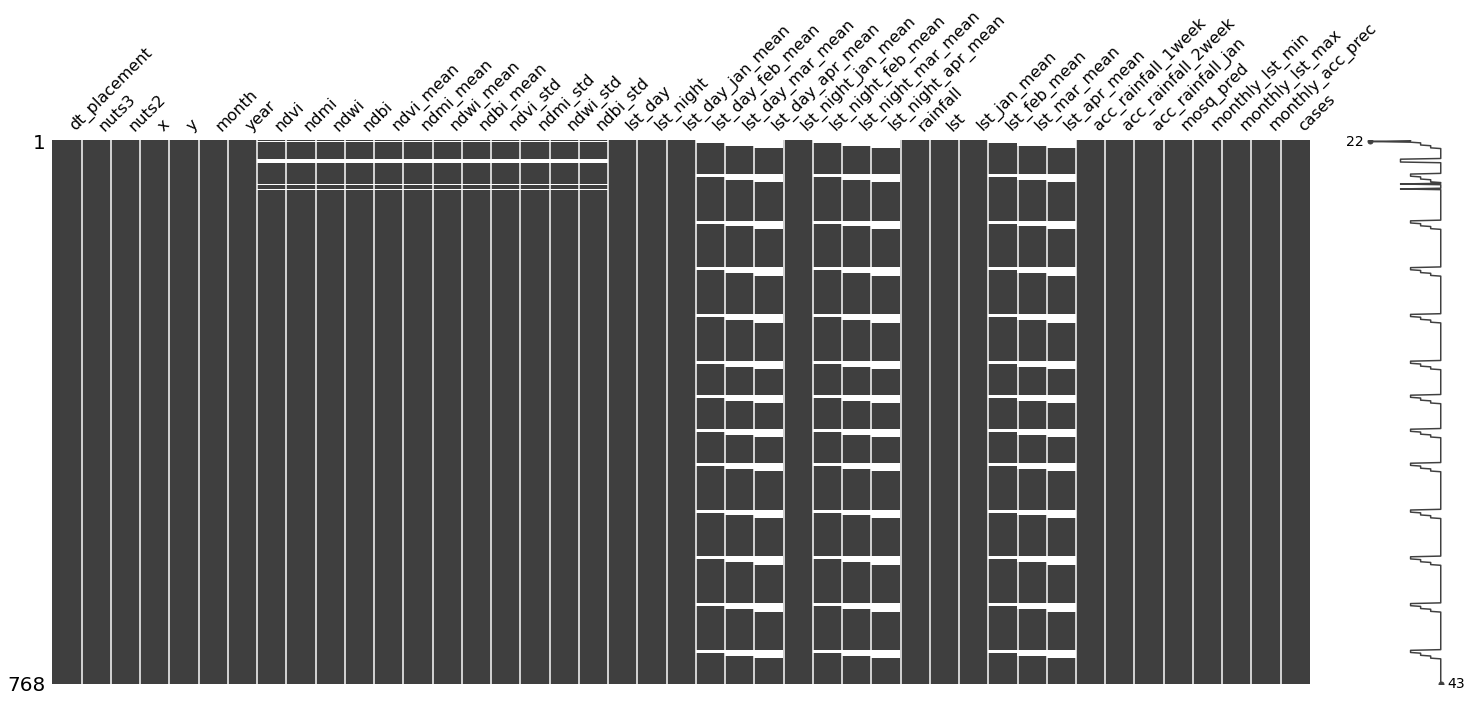

In [58]:
missingno.matrix(merged)

In [59]:
missing = describe_dataframe(merged)
missing

,Column,Missing
0,dt_placement,0.000000
1,nuts3,0.000000
2,nuts2,0.000000
3,x,0.000000
4,y,0.000000
5,month,0.000000
6,year,0.000000
7,ndvi,1.041700
8,ndmi,1.041700
9,ndwi,1.041700


In [60]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'monthly_lst_min', 'monthly_lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['monthly_lst_min', 'monthly_lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

In [61]:
missing = describe_dataframe(merged)
missing

,Column,Missing
0,dt_placement,0.000000
1,nuts3,0.000000
2,nuts2,0.000000
3,x,0.000000
4,y,0.000000
5,month,0.000000
6,year,0.000000
7,ndvi,1.041700
8,ndmi,1.041700
9,ndwi,1.041700


In [62]:
years = merged.year.unique()
years

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022])

In [63]:
nuts3_units = merged.nuts3.unique()
nuts3_units

array(['αθηνων', 'ανατολικης αττικης', 'δυτικης αττικης',
       'πειραιως και νησων'], dtype=object)

In [64]:
rows = []
for year in years:
    for region in nuts3_units:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['nuts3'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['monthly_lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['monthly_lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['monthly_acc_prec'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'nuts3': region, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [65]:
biovars_df.head(20)

,nuts3,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,αθηνων,2010,20.458333,19.583333,44.507576,871.116925,44.000000,0.000000,44.000000,15.333333,31.500000,31.500000,9.666667,810.000000,203.000000,0.000000,84.592554,329.000000,58.000000,58.000000,321.000000
1,ανατολικης αττικης,2010,19.416667,21.000000,47.727273,855.685088,44.000000,0.000000,44.000000,14.500000,30.500000,30.500000,9.333333,868.000000,219.000000,0.000000,83.901842,363.000000,71.000000,71.000000,342.000000
2,δυτικης αττικης,2010,19.125000,21.083333,47.916667,867.369325,44.000000,0.000000,44.000000,19.333333,30.500000,30.500000,9.166667,846.000000,217.000000,0.000000,82.107010,343.000000,63.000000,63.000000,303.000000
3,πειραιως και νησων,2010,19.958333,18.250000,45.625000,788.110033,42.000000,2.000000,40.000000,15.833333,29.333333,30.000000,10.500000,1370.000000,362.000000,2.000000,88.219002,630.000000,95.000000,125.000000,511.000000
4,αθηνων,2011,23.433333,20.000000,47.619048,780.222485,42.000000,0.000000,42.000000,9.666667,31.500000,31.500000,8.833333,2128.000000,314.000000,0.000000,99.689015,635.000000,0.000000,0.000000,617.000000
5,ανατολικης αττικης,2011,17.583333,20.000000,47.619048,878.488716,42.000000,0.000000,42.000000,8.666667,28.666667,28.833333,8.000000,1257.000000,321.000000,0.000000,87.832847,649.000000,22.000000,82.000000,634.000000
6,δυτικης αττικης,2011,17.250000,19.666667,47.967480,891.245298,41.000000,0.000000,41.000000,8.500000,28.833333,28.833333,7.666667,1203.000000,293.000000,0.000000,85.341485,625.000000,32.000000,69.000000,599.000000
7,πειραιως και νησων,2011,18.333333,17.000000,42.500000,815.846836,40.000000,0.000000,40.000000,9.833333,28.666667,28.833333,9.833333,1536.000000,318.000000,2.000000,82.714569,755.000000,51.000000,76.000000,727.000000
8,αθηνων,2012,25.366667,21.133333,48.030303,759.415989,44.000000,0.000000,44.000000,8.500000,30.000000,33.500000,8.500000,1619.000000,259.000000,0.000000,120.333389,593.000000,0.000000,0.000000,593.000000
9,ανατολικης αττικης,2012,19.625000,21.416667,46.557971,902.553197,44.000000,-2.000000,46.000000,8.000000,30.333333,30.333333,8.000000,1080.000000,262.000000,0.000000,100.495528,593.000000,24.000000,24.000000,593.000000


In [66]:
merged = pd.merge(merged, biovars_df,  how='left', on=['nuts3', 'year'])

In [68]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2010) & (merged['nuts3'] == 'αθηνων')]

,dt_placement,nuts3,nuts2,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2010-01,αθηνων,αττικης,23.761339,37.995939,1,2010,0.214667,0.115770,-0.078831,-0.115770,0.203206,0.109475,-0.076622,-0.109475,0.042789,0.028909,0.031819,0.028909,12.516682,6.346766,14.751865,NaN,NaN,NaN,8.568003,NaN,NaN,NaN,3.697714,9.431439,11.659648,NaN,NaN,NaN,24.216369,40.673503,45.577861,97,0.007500,18.517143,114.629143,0,20.458333,19.583333,44.507576,871.116925,44.000000,0.000000,44.000000,15.333333,31.500000,31.500000,9.666667,810.000000,203.000000,0.000000,84.592554,329.000000,58.000000,58.000000,321.000000
4,2010-02,αθηνων,αττικης,23.761339,37.995939,2,2010,0.170071,0.080282,-0.093162,-0.080282,0.165450,0.077220,-0.091478,-0.077220,0.032154,0.021483,0.020596,0.021483,13.964286,7.778533,12.516682,11.759552,NaN,NaN,6.344478,6.162053,NaN,NaN,4.657489,10.871409,9.430580,8.960803,NaN,NaN,34.319534,76.056410,205.750671,33,1.092857,18.563929,130.409681,0,20.458333,19.583333,44.507576,871.116925,44.000000,0.000000,44.000000,15.333333,31.500000,31.500000,9.666667,810.000000,203.000000,0.000000,84.592554,329.000000,58.000000,58.000000,321.000000
8,2010-03,αθηνων,αττικης,23.761339,37.995939,3,2010,0.205795,0.055235,-0.175050,-0.055235,0.206602,0.054431,-0.176687,-0.054431,0.036755,0.022774,0.024317,0.022774,19.857776,10.685253,12.516682,13.964286,19.420454,NaN,6.344478,7.778533,10.861502,NaN,1.899257,15.271515,9.430580,10.871409,15.140978,NaN,13.373182,27.695923,289.512050,66,6.290714,24.695714,58.876981,0,20.458333,19.583333,44.507576,871.116925,44.000000,0.000000,44.000000,15.333333,31.500000,31.500000,9.666667,810.000000,203.000000,0.000000,84.592554,329.000000,58.000000,58.000000,321.000000
12,2010-04,αθηνων,αττικης,23.761339,37.995939,4,2010,0.194310,0.052522,-0.168944,-0.052522,0.189741,0.052057,-0.164931,-0.052057,0.029583,0.020105,0.025067,0.020105,24.393667,12.564250,12.516682,13.964286,19.857776,22.621618,6.344478,7.778533,10.685253,12.604278,0.341008,18.478958,9.430580,10.871409,15.271515,17.612948,2.382667,4.397093,310.058717,385,9.462143,29.776786,10.230238,0,20.458333,19.583333,44.507576,871.116925,44.000000,0.000000,44.000000,15.333333,31.500000,31.500000,9.666667,810.000000,203.000000,0.000000,84.592554,329.000000,58.000000,58.000000,321.000000
16,2010-05,αθηνων,αττικης,23.761339,37.995939,5,2010,0.203285,0.033585,-0.213032,-0.033585,0.203429,0.032616,-0.214169,-0.032616,0.029421,0.019329,0.022993,0.019329,32.194862,17.530300,12.516682,13.964286,19.857776,19.857776,6.344478,7.778533,10.685253,10.685253,1.454263,24.862581,9.430580,10.871409,15.271515,15.271515,9.637039,18.153904,335.171956,680,14.778571,38.086786,45.082157,0,20.458333,19.583333,44.507576,871.116925,44.000000,0.000000,44.000000,15.333333,31.500000,31.500000,9.666667,810.000000,203.000000,0.000000,84.592554,329.000000,58.000000,58.000000,321.000000
20,2010-06,αθηνων,αττικης,23.761339,37.995939,6,2010,0.175277,0.017859,-0.193864,-0.017859,0.173232,0.016058,-0.192943,-0.016058,0.022269,0.019064,0.025355,0.019064,36.525048,22.120560,12.516682,13.964286,19.857776,19.857776,6.344478,7.778533,10.685253,10.685253,1.592195,29.322804,9.430580,10.871409,15.271515,15.271515,8.396058,13.986333,375.803195,1606,18.035357,44.708214,47.765864,0,20.458333,19.583333,44.507576,871.116925,44.000000,0.000000,44.000000,15.333333,31.500000,31.500000,9.666667,810.000000,203.000000,0.000000,84.592554,329.000000,58.000000,58.000000,321.000000
24,2010-07,αθηνων,αττικης,23.761339,37.995939,7,2010,

In [69]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [70]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [71]:
# df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()
##replace nuts3 code with the correct one
df_demographics_nuts2 = df_demographics.query(f"NUTS3_CODE.str.startswith('EL61')").copy()

In [94]:
code_to_name = {
    'EL611': 'καρδιτσας',
    'EL612': 'λαρισας',
    'EL613': 'μαγνησιας'
}

df_demographics_nuts2['NUTS3_NAME'] = df_demographics_nuts2['NUTS3_CODE'].map(code_to_name)

In [95]:
# df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.drop(columns=['NUTS3_CODE'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)
df_demographics_nuts2.rename(columns={'NUTS3_NAME': 'nuts3', 'YEAR': 'year'}, inplace=True)

In [96]:
df_demographics_nuts2

,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,nuts3
0,1991,26640.000000,85703.000000,18953.000000,131296.000000,24896.000000,83120.000000,24351.000000,132367.000000,καρδιτσας
1,1992,25762.000000,85463.000000,19664.000000,130889.000000,24202.000000,83240.000000,25158.000000,132600.000000,καρδιτσας
2,1993,25024.000000,85047.000000,20234.000000,130305.000000,23588.000000,83211.000000,25733.000000,132532.000000,καρδιτσας
3,1994,24219.000000,84560.000000,20939.000000,129718.000000,22831.000000,83067.000000,26338.000000,132236.000000,καρδιτσας
4,1995,23382.000000,84236.000000,21204.000000,128822.000000,22192.000000,83148.000000,26622.000000,131962.000000,καρδιτσας
5,1996,22660.000000,83593.000000,21693.000000,127946.000000,21379.000000,83147.000000,27166.000000,131692.000000,καρδιτσας
6,1997,21902.000000,82659.000000,22250.000000,126811.000000,20761.000000,83017.000000,27536.000000,131314.000000,καρδιτσας
7,1998,21094.000000,81944.000000,22708.000000,125746.000000,20168.000000,82670.000000,28093.000000,130931.000000,καρδιτσας
8,1999,20428.000000,80994.000000,23205.000000,124627.000000,19621.000000,82329.000000,28541.000000,130491.000000,καρδιτσας
9,2000,19799.000000,79438.000000,23905.000000,123142.000000,19116.000000,81502.000000,29349.000000,129967.000000,καρδιτσας


In [102]:
## specific to thessaly

df_demographics_nuts2_trikala = df_demographics_nuts2.loc[df_demographics_nuts2['nuts3'] == 'καρδιτσας'].copy()
df_demographics_nuts2_trikala['nuts3'] = 'τρικαλων'

df_demographics_nuts2 = df_demographics_nuts2.append(df_demographics_nuts2_trikala, ignore_index = True)

In [103]:
df_demographics_nuts2

,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,nuts3
0,1991,26640.000000,85703.000000,18953.000000,131296.000000,24896.000000,83120.000000,24351.000000,132367.000000,καρδιτσας
1,1992,25762.000000,85463.000000,19664.000000,130889.000000,24202.000000,83240.000000,25158.000000,132600.000000,καρδιτσας
2,1993,25024.000000,85047.000000,20234.000000,130305.000000,23588.000000,83211.000000,25733.000000,132532.000000,καρδιτσας
3,1994,24219.000000,84560.000000,20939.000000,129718.000000,22831.000000,83067.000000,26338.000000,132236.000000,καρδιτσας
4,1995,23382.000000,84236.000000,21204.000000,128822.000000,22192.000000,83148.000000,26622.000000,131962.000000,καρδιτσας
...,...,...,...,...,...,...,...,...,...,...
123,2018,15551.000000,71019.000000,30300.000000,116870.000000,14670.000000,68814.000000,36026.000000,119510.000000,τρικαλων
124,2019,15273.000000,70165.000000,30508.000000,115946.000000,14338.000000,68116.000000,36045.000000,118499.000000,τρικαλων
125,2020,14936.000000,69399.000000,30620.000000,114955.000000,14081.000000,67437.000000,35957.000000,117475.000000,τρικαλων
126,2021,14610.000000,68583.000000,30631.000000,113824.000000,13766.000000,66633.000000,35877.000000,116276.000000,τρικαλων


In [104]:
names_from_timeline = merged["nuts3"].drop_duplicates().sort_values().tolist()
names_from_wnv = df_demographics_nuts2["nuts3"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_timeline:
    if element not in names_from_wnv:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [105]:
# df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))


In [106]:
# names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
# names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_merged:
#     if element not in names_from_demographics:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")

In [107]:
dataset = pd.merge(merged, df_demographics_nuts2,  how='left', on=['nuts3', 'year'])

<AxesSubplot:>

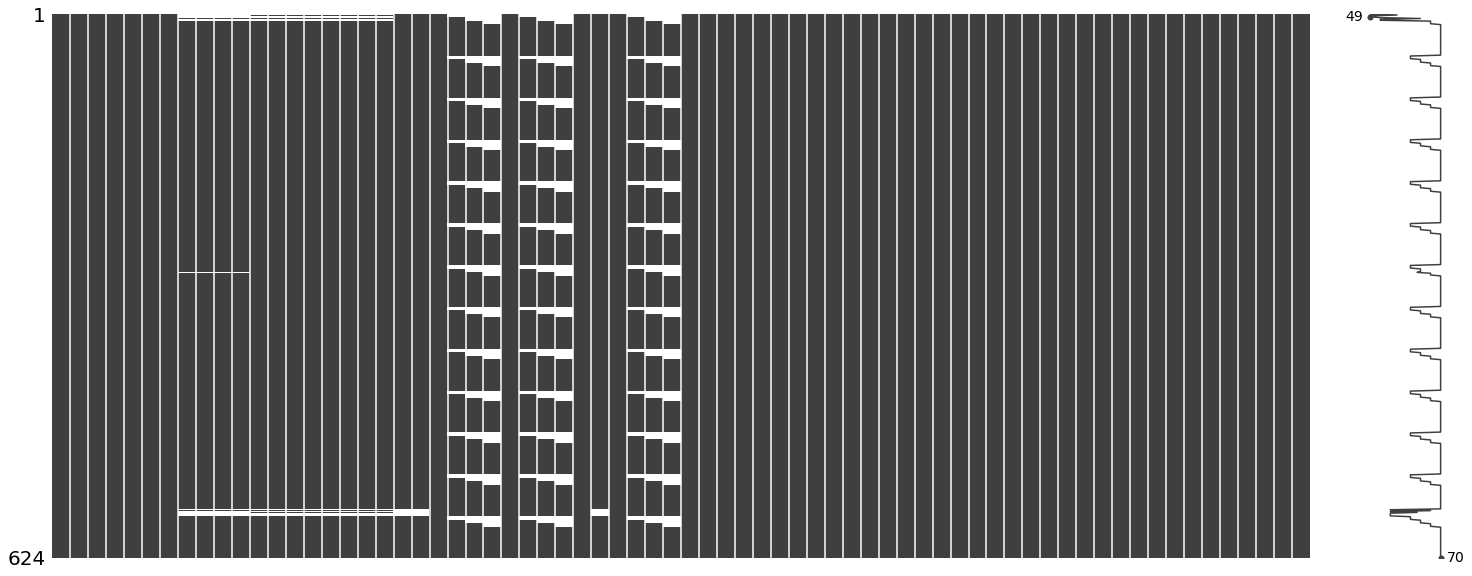

In [108]:
missingno.matrix(dataset)

In [109]:
df_economics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [110]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [111]:
## chose the right NUTS2 Code

df_economics_nuts2 = df_economics.query(f"NUTS3_CODE.str.startswith('EL61')").copy()

In [112]:
df_economics_nuts2['NUTS3_NAME'] = df_economics_nuts2['NUTS3_CODE'].map(code_to_name)
df_economics_nuts2.drop(columns=['NUTS3_CODE'], inplace=True)
df_economics_nuts2.reset_index(inplace=True, drop=True)
df_economics_nuts2.rename(columns={'NUTS3_NAME': 'nuts3', 'YEAR': 'year'}, inplace=True)

In [113]:
df_economics_nuts2

,year,MIO_EUR,nuts3
0,2000,2133.000000,καρδιτσας
1,2001,2333.720000,καρδιτσας
2,2002,2471.530000,καρδιτσας
3,2003,2738.630000,καρδιτσας
4,2004,2905.000000,καρδιτσας
5,2005,2846.530000,καρδιτσας
6,2006,2957.160000,καρδιτσας
7,2007,3192.360000,καρδιτσας
8,2008,3254.090000,καρδιτσας
9,2009,3296.180000,καρδιτσας


In [116]:
## specific to thessaly

df_economics_nuts2_trikala = df_economics_nuts2.loc[df_economics_nuts2['nuts3'] == 'καρδιτσας'].copy()
df_economics_nuts2_trikala['nuts3'] = 'τρικαλων'

df_economics_nuts2 = df_economics_nuts2.append(df_economics_nuts2_trikala, ignore_index = True)

In [117]:
names_from_timeline = dataset["nuts3"].drop_duplicates().sort_values().tolist()
names_from_economics = df_economics_nuts2["nuts3"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_timeline:
    if element not in names_from_economics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [118]:
dataset = pd.merge(dataset, df_economics_nuts2,  how='left', on=['nuts3', 'year'])

<AxesSubplot:>

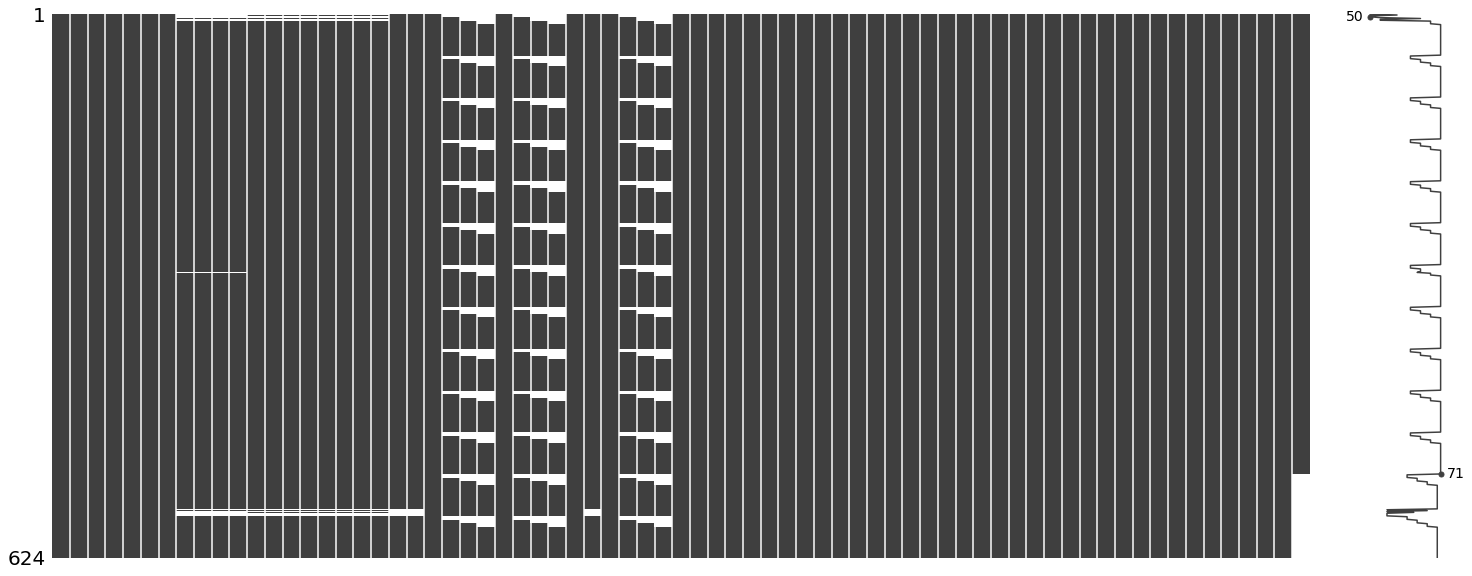

In [119]:
missingno.matrix(dataset)

In [120]:
df_trade = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [121]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [122]:
df_trade_nuts2 = df_trade.query(f"NUTS3_CODE.str.startswith('EL61')").copy()

In [123]:
df_trade_nuts2['NUTS3_NAME'] = df_trade_nuts2['NUTS3_CODE'].map(code_to_name)
df_trade_nuts2.drop(columns=['NUTS3_CODE'], inplace=True)
df_trade_nuts2.reset_index(inplace=True, drop=True)
df_trade_nuts2.rename(columns={'NUTS3_NAME': 'nuts3', 'YEAR': 'year'}, inplace=True)

In [124]:
df_trade_nuts2

,year,L_TOTAL,UNL_TOTAL,nuts3
0,2015,10352.000000,10375.000000,καρδιτσας
1,2016,23404.000000,23165.000000,καρδιτσας
2,2017,7816.000000,7614.000000,καρδιτσας
3,2018,5407.000000,5526.000000,καρδιτσας
4,2019,10375.000000,9909.000000,καρδιτσας
5,2020,8644.000000,7197.000000,καρδιτσας
6,2021,6070.000000,6292.000000,καρδιτσας
7,2015,7604.000000,8362.000000,λαρισας
8,2016,5898.000000,5977.000000,λαρισας
9,2017,4061.000000,4578.000000,λαρισας


In [126]:
## specific to thessaly

df_trade_nuts2_trikala = df_trade_nuts2.loc[df_trade_nuts2['nuts3'] == 'καρδιτσας'].copy()
df_trade_nuts2_trikala['nuts3'] = 'τρικαλων'

df_trade_nuts2 = df_trade_nuts2.append(df_trade_nuts2_trikala, ignore_index = True)

In [127]:
names_from_timeline = dataset["nuts3"].drop_duplicates().sort_values().tolist()
names_from_economics = df_trade_nuts2["nuts3"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_timeline:
    if element not in names_from_economics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [128]:
dataset = pd.merge(dataset, df_trade_nuts2,  how='left', on=['nuts3', 'year'])

<AxesSubplot:>

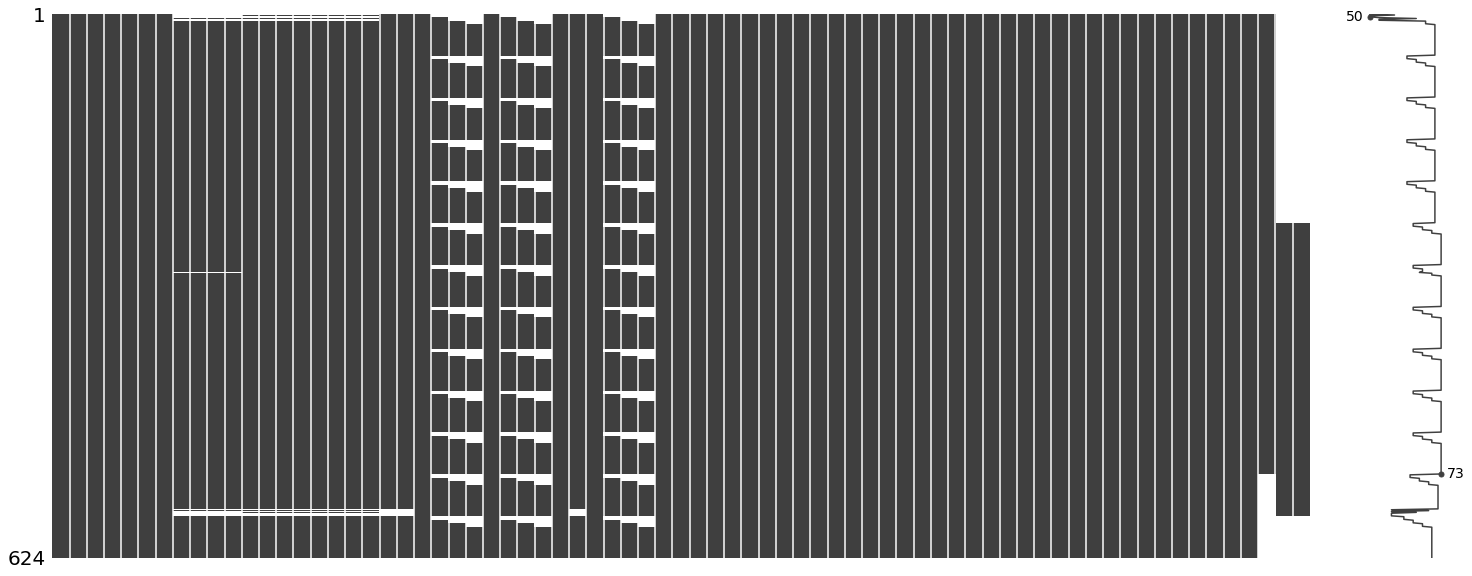

In [129]:
missingno.matrix(dataset)

In [130]:
missing = describe_dataframe(dataset)

In [131]:
missing

,Column,Missing
0,dt_placement,0.000000
1,nuts3,0.000000
2,nuts2,0.000000
3,x,0.000000
4,y,0.000000
5,month,0.000000
6,year,0.000000
7,ndvi,2.403800
8,ndmi,2.403800
9,ndwi,2.403800


In [132]:
dataset

,dt_placement,nuts3,nuts2,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,καρδιτσας,θεσσαλιας,21.891852,39.318887,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.599074,1.905654,9.822247,NaN,NaN,NaN,2.800149,NaN,NaN,NaN,6.251319,4.637507,6.273465,NaN,NaN,NaN,38.879179,66.769128,107.297640,31,-0.476829,16.250750,193.790875,0,16.333333,20.000000,47.619048,810.536672,39.000000,-3.000000,42.000000,15.500000,26.666667,26.666667,6.833333,1615.000000,293.000000,8.000000,64.278800,626.000000,120.000000,120.000000,586.000000,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN
1,2010-01,λαρισας,θεσσαλιας,22.405497,39.703383,1,2010,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,10.141210,1.954030,12.702802,NaN,NaN,NaN,3.256673,NaN,NaN,NaN,3.023659,6.031580,7.963884,NaN,NaN,NaN,17.839457,28.583378,35.862492,35,-0.715704,15.911704,93.733414,0,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.000000,62.577013,550.000000,158.000000,158.000000,378.000000,23344.000000,94158.000000,25983.000000,143485.000000,22094.000000,93589.000000,31108.000000,146791.000000,4654.450000,NaN,NaN
2,2010-01,μαγνησιας,θεσσαλιας,22.869212,39.281871,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.030960,3.318312,12.481640,NaN,NaN,NaN,4.902586,NaN,NaN,NaN,4.854475,6.664236,8.682121,NaN,NaN,NaN,29.967839,47.912827,55.731474,31,0.040625,16.806170,150.488717,0,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000,15287.000000,68105.000000,17655.000000,101047.000000,14898.000000,67890.000000,22944.000000,105732.000000,3102.990000,NaN,NaN
3,2010-01,τρικαλων,θεσσαλιας,21.591863,39.641569,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.156233,1.226071,6.544535,NaN,NaN,NaN,2.019501,NaN,NaN,NaN,7.016475,3.365383,4.478655,NaN,NaN,NaN,43.471823,78.133518,125.600602,75,-1.336788,15.217500,217.510733,0,14.458333,19.250000,45.833333,792.423880,38.000000,-4.000000,42.000000,14.333333,24.500000,24.500000,5.166667,2288.000000,390.000000,10.000000,63.081352,951.000000,159.000000,159.000000,787.000000,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN
4,2010-02,καρδιτσας,θεσσαλιας,21.891852,39.318887,2,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.784100,2.134017,6.257236,7.375588,NaN,NaN,1.861080,0.451500,NaN,NaN,9.188262,6.013671,4.060509,3.969706,NaN,NaN,66.090110,130.146525,325.793294,130,-2.275500,15.057154,257.271323,0,16.333333,20.000000,47.619048,810.536672,39.000000,-3.000000,42.000000,15.500000,26.666667,26.666667,6.833333,1615.000000,293.000000,8.000000,64.278800,626.000000,120.000000,120.000000,586.000000,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [133]:
dataset.reset_index(inplace=True, drop=True)

In [134]:
dataset['cases'].value_counts()

0     591
1       8
2       7
4       5
5       3
3       3
7       2
6       2
15      1
19      1
23      1
Name: cases, dtype: int64

In [135]:
dataset['cases'].sum()

149

In [136]:
dataset

,dt_placement,nuts3,nuts2,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,καρδιτσας,θεσσαλιας,21.891852,39.318887,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.599074,1.905654,9.822247,NaN,NaN,NaN,2.800149,NaN,NaN,NaN,6.251319,4.637507,6.273465,NaN,NaN,NaN,38.879179,66.769128,107.297640,31,-0.476829,16.250750,193.790875,0,16.333333,20.000000,47.619048,810.536672,39.000000,-3.000000,42.000000,15.500000,26.666667,26.666667,6.833333,1615.000000,293.000000,8.000000,64.278800,626.000000,120.000000,120.000000,586.000000,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN
1,2010-01,λαρισας,θεσσαλιας,22.405497,39.703383,1,2010,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,10.141210,1.954030,12.702802,NaN,NaN,NaN,3.256673,NaN,NaN,NaN,3.023659,6.031580,7.963884,NaN,NaN,NaN,17.839457,28.583378,35.862492,35,-0.715704,15.911704,93.733414,0,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.000000,62.577013,550.000000,158.000000,158.000000,378.000000,23344.000000,94158.000000,25983.000000,143485.000000,22094.000000,93589.000000,31108.000000,146791.000000,4654.450000,NaN,NaN
2,2010-01,μαγνησιας,θεσσαλιας,22.869212,39.281871,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.030960,3.318312,12.481640,NaN,NaN,NaN,4.902586,NaN,NaN,NaN,4.854475,6.664236,8.682121,NaN,NaN,NaN,29.967839,47.912827,55.731474,31,0.040625,16.806170,150.488717,0,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000,15287.000000,68105.000000,17655.000000,101047.000000,14898.000000,67890.000000,22944.000000,105732.000000,3102.990000,NaN,NaN
3,2010-01,τρικαλων,θεσσαλιας,21.591863,39.641569,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.156233,1.226071,6.544535,NaN,NaN,NaN,2.019501,NaN,NaN,NaN,7.016475,3.365383,4.478655,NaN,NaN,NaN,43.471823,78.133518,125.600602,75,-1.336788,15.217500,217.510733,0,14.458333,19.250000,45.833333,792.423880,38.000000,-4.000000,42.000000,14.333333,24.500000,24.500000,5.166667,2288.000000,390.000000,10.000000,63.081352,951.000000,159.000000,159.000000,787.000000,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN
4,2010-02,καρδιτσας,θεσσαλιας,21.891852,39.318887,2,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.784100,2.134017,6.257236,7.375588,NaN,NaN,1.861080,0.451500,NaN,NaN,9.188262,6.013671,4.060509,3.969706,NaN,NaN,66.090110,130.146525,325.793294,130,-2.275500,15.057154,257.271323,0,16.333333,20.000000,47.619048,810.536672,39.000000,-3.000000,42.000000,15.500000,26.666667,26.666667,6.833333,1615.000000,293.000000,8.000000,64.278800,626.000000,120.000000,120.000000,586.000000,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [137]:
cols = dataset.columns

In [138]:
cols

Index(['dt_placement', 'nuts3', 'nuts2', 'x', 'y', 'month', 'year', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_day_jan_mean', 'lst_day_feb_mean', 'lst_day_mar_mean',
       'lst_day_apr_mean', 'lst_night_jan_mean', 'lst_night_feb_mean',
       'lst_night_mar_mean', 'lst_night_apr_mean', 'rainfall', 'lst',
       'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'mosq_pred', 'monthly_lst_min', 'monthly_lst_max', 'monthly_acc_prec',
       'cases', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8',
       'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16',
       'bio17', 'bio18', 'bio19', 'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65',
       'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL', 'MIO_EUR',
       'L_TOTAL', 'UNL_TOTAL']

In [139]:
len(cols)

73

In [140]:
# check columns

In [141]:
final_columns = ['x', 'y', 'month', 'year', 'dt_placement', 'nuts2', 'nuts3',
                 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
                 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std',
                 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8',
                 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16',
                 'bio17', 'bio18', 'bio19', 
                 'lst', 'lst_day', 'lst_night', 'monthly_lst_min', 'monthly_lst_max',
                 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean',
                 'lst_day_jan_mean', 'lst_day_feb_mean', 'lst_day_mar_mean', 'lst_day_apr_mean', 
                 'lst_night_jan_mean', 'lst_night_feb_mean', 'lst_night_mar_mean', 'lst_night_apr_mean', 
                 'rainfall', 'monthly_acc_prec', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65', 'M_TOTAL',
                 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL', 
                 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL','mosq_pred', 'cases']

In [142]:
len(final_columns)

73

In [143]:
dataset_final = dataset[final_columns].copy()

In [144]:
dataset_final

,x,y,month,year,dt_placement,nuts2,nuts3,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases
0,21.891852,39.318887,1,2010,2010-01,θεσσαλιας,καρδιτσας,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.333333,20.000000,47.619048,810.536672,39.000000,-3.000000,42.000000,15.500000,26.666667,26.666667,6.833333,1615.000000,293.000000,8.000000,64.278800,626.000000,120.000000,120.000000,586.000000,4.637507,7.599074,1.905654,-0.476829,16.250750,6.273465,NaN,NaN,NaN,9.822247,NaN,NaN,NaN,2.800149,NaN,NaN,NaN,6.251319,193.790875,38.879179,66.769128,107.297640,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN,31,0
1,22.405497,39.703383,1,2010,2010-01,θεσσαλιας,λαρισας,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,17.291667,21.583333,47.962963,881.233210,42.000000,-3.000000,45.000000,17.166667,28.333333,28.333333,6.666667,1371.000000,275.000000,22.000000,62.577013,550.000000,158.000000,158.000000,378.000000,6.031580,10.141210,1.954030,-0.715704,15.911704,7.963884,NaN,NaN,NaN,12.702802,NaN,NaN,NaN,3.256673,NaN,NaN,NaN,3.023659,93.733414,17.839457,28.583378,35.862492,23344.000000,94158.000000,25983.000000,143485.000000,22094.000000,93589.000000,31108.000000,146791.000000,4654.450000,NaN,NaN,35,0
2,22.869212,39.281871,1,2010,2010-01,θεσσαλιας,μαγνησιας,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.333333,19.000000,46.341463,808.571505,40.000000,-1.000000,41.000000,17.000000,27.666667,27.666667,7.833333,1243.000000,266.000000,10.000000,67.794059,476.000000,129.000000,129.000000,391.000000,6.664236,10.030960,3.318312,0.040625,16.806170,8.682121,NaN,NaN,NaN,12.481640,NaN,NaN,NaN,4.902586,NaN,NaN,NaN,4.854475,150.488717,29.967839,47.912827,55.731474,15287.000000,68105.000000,17655.000000,101047.000000,14898.000000,67890.000000,22944.000000,105732.000000,3102.990000,NaN,NaN,31,0
3,21.591863,39.641569,1,2010,2010-01,θεσσαλιας,τρικαλων,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.458333,19.250000,45.833333,792.423880,38.000000,-4.000000,42.000000,14.333333,24.500000,24.500000,5.166667,2288.000000,390.000000,10.000000,63.081352,951.000000,159.000000,159.000000,787.000000,3.365383,5.156233,1.226071,-1.336788,15.217500,4.478655,NaN,NaN,NaN,6.544535,NaN,NaN,NaN,2.019501,NaN,NaN,NaN,7.016475,217.510733,43.471823,78.133518,125.600602,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN,75,0
4,21.891852,39.318887,2,2010,2010-02,θεσσαλιας,καρδιτσας,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.333333,20.000000,47.619048,810.536672,39.000000,-3.000000,42.000000,15.500000,26.666667,26.666667,6.833333,1615.000000,293.000000,8.000000,64.278800,626.000000,120.000000,120.000000,586.000000,6.013671,9.784100,2.134017,-2.275500,15.057154,4.060509,3.969706,NaN,NaN,6.257236,7.375588,NaN,NaN,1.861080,0.451500,NaN,NaN,9.188262,257.271323,66.090110,130.146525,325.793294,17404.000000,77291.000000,28372.000000,123067.000000,16953.000000,74300.000000,35601.000000,126854.000000,3007.130000,NaN,NaN,130,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

<AxesSubplot:>

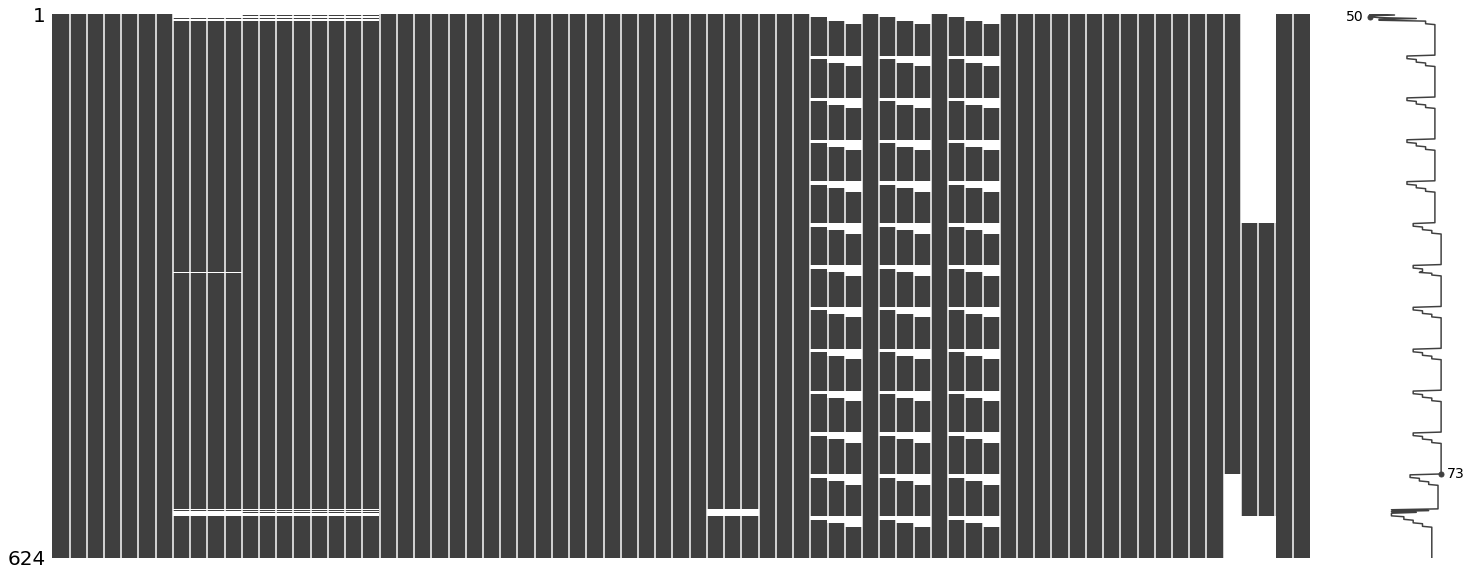

In [145]:
missingno.matrix(dataset_final)

In [146]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022.csv", encoding = enc, index = False)